In [ ]:
!pip install -U ultralytics roboflow supervision -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 149.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00


## Connect Content Colab
Mount MyDrive in Colab content/


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


##  Link to My Project Directory in Drive

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/SphinxPV2"

print(f"Folder is Set: {BASE_DIR}")

Folder is Set: /content/drive/MyDrive/SphinxPV2


## Import Libs  I

In [ ]:
import os
import subprocess
import torch
from ultralytics import YOLO
from pathlib import Path
from collections import Counter
from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### This is the path to my best.pt from v2

In [ ]:
V1_MODEL_PATH = f"{BASE_DIR}/sphinx_eyes_v2f/weights/best.pt"

In [ ]:
print(f"Searching best model from v1 : {V1_MODEL_PATH}")

Searching best model from v1 : /content/drive/MyDrive/SphinxPV2/sphinx_eyes_v2f/weights/best.pt


In [ ]:
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✓ GPU: {gpu_name} | VRAM: {vram:.1f} GB")

✓ GPU: NVIDIA L4 | VRAM: 23.7 GB


In [ ]:
# Load the model from v2 that predict 150 clases
model = YOLO(V1_MODEL_PATH)
print("First model v1 is load in content.")

First model v1 is load in content.


In [ ]:
!pip install roboflow


##  Fetch dataset from My Roboflow Project
It has 250 high resolution images
over 9500 glyphs , it made up ~ 36 glyphs / images

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="My-Roboflow-API-Key")
project = rf.workspace("myworkspace-rde28").project("sphinx_project")
version = project.version(5)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sphinx_Project-5 in yolov11:: 100%|██████████| 1837/1837 [00:00<00:00, 4701.85it/s]


## Check dataset Integrity from Roboflow now in contet/

In [ ]:
!ls -la {dataset.location}

total 24
drwxr-xr-x 4 root root 4096 May 22 21:29 .
drwxr-xr-x 1 root root 4096 May 22 21:29 ..
-rw-r--r-- 1 root root 1846 May 22 21:29 data.yaml
-rw-r--r-- 1 root root 1245 May 22 21:29 README.roboflow.txt
drwxr-xr-x 4 root root 4096 May 22 21:29 train
drwxr-xr-x 4 root root 4096 May 22 21:29 valid


In [ ]:
import random
import shutil

## Validate Hardware  in Colab

In [ ]:
# Validate GPU Hardware
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Fri May 22 21:29:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   36C    P8             16W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Set Gardiner List First Time.
It will be usefull for upcoming changes

In [ ]:
gardiner_names = ["Aa1", "a1", "a2", "a24", "a30", "a40", "a42", "a50", "b1", "cartouche", "d1", "d2", "d4", "d10", "d21", "d28", "d35", "d36", "d37", "d39", "d40", "d45", "d46", "d54", "d55", "d56", "d58", "d60", "e1", "e7", "e10", "e16", "e23", "e34", "f1", "f4", "f12", "f13", "f26", "f31", "f32", "f35", "f39", "f51", "g1", "g5", "g7", "g14", "g17", "g25", "g36", "g39", "g40", "g41", "g43", "h1", "h6", "i1", "i9", "i10", "i12", "i15", "l1", "l2", "m2", "m3", "m12", "m16", "m17", "m18", "m20", "m22", "m23", "m24", "m42", "n1", "n5", "n8", "n14", "n17", "n23", "n25", "n26", "n27", "n29", "n33", "n35", "n36", "n37", "o1", "o3", "o4", "o6", "o28", "o34", "o49", "p1", "p3", "q1", "q3", "r4", "r7", "r8", "r11", "s3", "s19", "s28", "s29", "s34", "s38", "s40", "t22", "t28", "t30", "u1", "u6", "u15", "u23", "u33", "u36", "unknown", "v4", "v6", "v7", "v13", "v20", "v28", "v29", "v30", "v31", "w10", "w14", "w17", "w19", "w22", "w24", "w25", "x1", "x8", "y1", "y2", "y3", "y5", "z1", "z2", "z3", "z4", "z7", "z11", "Aa15"]

In [ ]:
import os

In [ ]:
from pathlib import Path
from collections import Counter

In [ ]:
edited = 0
corrected = 0

In [ ]:
label_dirs = [
    Path(f"{dataset.location}/train/labels"),
    Path(f"{dataset.location}/valid/labels")
]

In [ ]:
for l_dir in label_dirs:
    for txt_file in l_dir.glob('*.txt'):
        with open(txt_file, 'r') as f:
            lines = f.readlines()

        new_lines = []
        edited = False

        for line in lines:
            parts = line.strip().split()
            if not parts: continue

            cls_id = int(parts[0])
            # Si el ID es 127 o mayor, fue desplazado por Roboflow. Lo devolvemos a su lugar (+1)
            if cls_id >= 127:
                cls_id += 1
                edited = True
                corrected  += 1

            # Reconstruimos la línea YOLO
            new_line = f"{cls_id} " + " ".join(parts[1:]) + "\n"
            new_lines.append(new_line)

        if edited:
            with open(txt_file, 'w') as f:
                f.writelines(new_lines)
            edited += 1

## Fix two zero signs clases mismatched

In [ ]:
print(f"  Fix cdone.")
print(f"  edited files: {edited}")
print(f"  corrected annotations (Shifted +1): {corrected}")

  Fix cdone.
  edited files: 2
  corrected annotations (Shifted +1): 6937


## Check Current Labels
They must match within my inner Sorting from v2.

Confrim Numbr of Instance total from Roboflow dataset

In [ ]:
label_dir = Path(f"{dataset.location}/train/labels")
class_counts = Counter()

for txt in label_dir.glob('*.txt'):
    with open(txt) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counts[int(parts[0])] += 1

print("Class IDs Found is in files  .txt:")
for cls_id, count in sorted(class_counts.items()):
    name = gardiner_names[cls_id] if cls_id < 150 else "OUT OF RANGE"
    print(f"  ID {cls_id:3d} : {name:15s}: {count} intstances ")

Class IDs Found is in files  .txt:
  ID   0 : Aa1            : 350 intstances 
  ID   1 : a1             : 294 intstances 
  ID   2 : a2             : 96 intstances 
  ID   3 : a24            : 52 intstances 
  ID   4 : a30            : 28 intstances 
  ID   5 : a40            : 167 intstances 
  ID   6 : a42            : 156 intstances 
  ID   7 : a50            : 92 intstances 
  ID   8 : b1             : 195 intstances 
  ID   9 : cartouche      : 644 intstances 
  ID  10 : d1             : 92 intstances 
  ID  11 : d2             : 175 intstances 
  ID  12 : d4             : 473 intstances 
  ID  13 : d10            : 28 intstances 
  ID  14 : d21            : 1214 intstances 
  ID  15 : d28            : 188 intstances 
  ID  16 : d35            : 143 intstances 
  ID  17 : d36            : 416 intstances 
  ID  18 : d37            : 184 intstances 
  ID  19 : d39            : 44 intstances 
  ID  20 : d40            : 56 intstances 
  ID  21 : d45            : 12 intstances 
  ID 

In [ ]:
!ls -la {dataset.location} | wc -l

7


In [ ]:
import yaml

This is the Overall Gardiner List My Model Predict.


It Predict 148 real gardiner signs base on frequency in Middle Egypt + Cartouche + Unkown .

In [ ]:
gardiner_names = [
    "Aa1","a1","a2","a24","a30","a40","a42","a50","b1","cartouche",
    "d1","d2","d4","d10","d21","d28","d35","d36","d37","d39",
    "d40","d45","d46","d54","d55","d56","d58","d60","e1","e7",
    "e10","e16","e23","e34","f1","f4","f12","f13","f26","f31",
    "f32","f35","f39","f51","g1","g5","g7","g14","g17","g25",
    "g36","g39","g40","g41","g43","h1","h6","i1","i9","i10",
    "i12","i15","l1","l2","m2","m3","m12","m16","m17","m18",
    "m20","m22","m23","m24","m42","n1","n5","n8","n14","n17",
    "n23","n25","n26","n27","n29","n33","n35","n36","n37","o1",
    "o3","o4","o6","o28","o34","o49","p1","p3","q1","q3",
    "r4","r7","r8","r11","s3","s19","s28","s29","s34","s38",
    "s40","t22","t28","t30","u1","u6","u15","u23","u33","u36",
    "unknown","v4","v6","v7","v13","v20","v28","v29","v30","v31",
    "w10","w14","w17","w19","w22","w24","w25","x1","x8","y1",
    "y2","y3","y5","z1","z2","z3","z4","z7","z11","Aa15"
]

In [ ]:
data_yaml_path = f"{dataset.location}/data.yaml"

In [ ]:
config = {
    'path' : dataset.location,
    'train': f"{dataset.location}/train/images",
    'val'  : f"{dataset.location}/valid/images",
    'nc'   : 150,
    'names': gardiner_names
}

In [ ]:
with open(data_yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)

In [ ]:
print("✓ data.yaml All Clear")
print(f"  nc: 150")
print(f"  Class 0: {gardiner_names[0]}")
print(f"  Class 149: {gardiner_names[149]}")

✓ data.yaml All Clear
  nc: 150
  Class 0: Aa1
  Class 149: Aa15


### Confrim dataset split directories before moving ahead


In [ ]:
train_images_dir = Path(f"{dataset.location}/train/images")
train_labels_dir = Path(f"{dataset.location}/train/labels")
val_images_dir = Path(f"{dataset.location}/valid/images")
val_labels_dir = Path(f"{dataset.location}/valid/labels")

In [ ]:
val_images_dir.mkdir(parents=True, exist_ok=True)
val_labels_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
all_train_images = []
num_to_move = 50

In [ ]:
for ext in ['*.jpg', '*.jpeg', '*.png']:
    all_train_images.extend(list(train_images_dir.glob(ext)))

## Ensure unique image paths in case of previous accidental duplication

In [ ]:
all_train_images = list(set(all_train_images))

num_to_move = 76

if len(all_train_images) < num_to_move:
    print(f"[Error]: it only exist {len(all_train_images)} images, not existr {num_to_move}.")
else:
    # Random split
    images_to_move = random.sample(all_train_images, num_to_move)

    moved_count = 0
    missing_labels = 0

    for img_path in images_to_move:
        base_name = img_path.stem # cut img ext

        # dir path
        dest_img_path = val_images_dir / img_path.name

        # path to folder
        label_name = base_name + ".txt"
        src_label_path = train_labels_dir / label_name
        dest_label_path = val_labels_dir / label_name

        # move images
        # Check if the source file still exists before moving
        if img_path.exists():
            shutil.move(str(img_path), str(dest_img_path))
        else:
            print(f"Warning: Image {img_path.name} not found in source, might have been moved already.")
            continue # Skip to next image if source not found

        # move labels
        if src_label_path.exists():
            shutil.move(str(src_label_path), str(dest_label_path))
            moved_count += 1
        else:
            missing_labels += 1
            print(f"Warning missing lables  {img_path.name}")

    print(f"Replacmeent re-split done.")
    print(f" All Pairs done: {moved_count}")
    if missing_labels > 0:
        print(f"  missing no found tags : {missing_labels}")

Replacmeent re-split done.
 All Pairs done: 75


In [ ]:
final_train_imgs = len(list(train_images_dir.glob('*.*')))
final_val_imgs = len(list(val_images_dir.glob('*.*')))

In [ ]:
print(f"\Dataset it is balance nowt:")
print(f"  Total imgs in Train: {final_train_imgs} images")
print(f"  Total images in Val  : {final_val_imgs} images")

\Dataset it is balance nowt:
  Total imgs in Train: 776 images
  Total images in Val  : 141 images


invalid escape sequence '\D'
invalid escape sequence '\D'
invalid escape sequence '\D'


## Fetch Second Dataset from My Drive,
Auxiliar dataset for the low freq number classes

In [ ]:
import yaml
data_yaml_path = f"{dataset.location}/data.yaml"

In [ ]:
with open(data_yaml_path, 'r') as f:
    config = yaml.safe_load(f)

In [ ]:
config['names'] = gardiner_names
config['nc'] = 150

config['train'] = f"{dataset.location}/train/images"
config['val'] = f"{dataset.location}/valid/images"

In [ ]:
with open(data_yaml_path, 'w') as f:
    yaml.dump(config, f)
print(f"✓ data.yaml update 150 classes {data_yaml_path}")

✓ data.yaml update 150 classes /content/Sphinx_Project-5/data.yaml


In [ ]:
label_dir = Path(f"{dataset.location}/train/labels")
class_counts = Counter()

## Check Dataset Integrity II

In [ ]:
if label_dir.exists():
    for txt in label_dir.glob('*.txt'):
        with open(txt) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    class_counts[cls_id] += 1

    # Clases con 0 instancias en este set de 75 imágenes
    zeros = [gardiner_names[i] for i in range(150) if class_counts[i] == 0]
    print(f"\nRoboflow dataet report v2:")
    print(f"Total Classes with 0 instances v2: {len(zeros)}")
    print(f"Clases presentes: {150 - len(zeros)}")

    print(f"\nTop 10 most feequenct Claasses :")
    for cls_id, count in class_counts.most_common(10):
        if cls_id < len(gardiner_names):
            print(f"  {gardiner_names[cls_id]:12s}: {count}")
else:
    print("Tag not found , check directory again .")


Roboflow dataet report v2:
Total Classes with 0 instances v2: 3
Clases presentes: 147

Top 10 most feequenct Claasses :
  x1          : 2050
  n35         : 1634
  m17         : 1147
  d21         : 1070
  g43         : 1002
  unknown     : 917
  i9          : 901
  g17         : 864
  v30         : 609
  z1          : 602


In [ ]:
ZIP_PATH =  '/content/drive/MyDrive/datasetv2.zip'

In [ ]:
if os.path.exists(ZIP_PATH):
    size_gb = os.path.getsize(ZIP_PATH) / 1e9
    print(f'✓ Found: {ZIP_PATH} ({size_gb:.2f} GB)')
else:
    print(f'✗ NOT FOUND: {ZIP_PATH}')
    print('Adjust ZIP_PATH to match your Drive location')

✓ Found: /content/drive/MyDrive/datasetv2.zip (0.05 GB)


In [ ]:
print('Extracting files in content/ ')
!unzip -q "{ZIP_PATH}" -d /content/


Extracting files in content/ 


In [ ]:
print('\nStructure:')
!ls /content/TrainingV2/
print('\nImages train:')
!ls /content/TrainingV2/images/ | wc -l
print('Labels :')
!ls /content/TrainingV2/labels/ | wc -l




Structure:
class_map.json	dataset.yaml  images  labels

Images train:
224
Labels :
224


In [ ]:
import yaml, json, random
from pathlib import Path

In [ ]:
DATASET_YAML = '/content/TrainingV2/dataset.yaml'

In [ ]:
with open(DATASET_YAML) as f:
    cfg = yaml.safe_load(f)

In [ ]:
print(f'Classes (nc) : {cfg["nc"]}')
print(f'Train        : {cfg["train"]}')
print(f'Val          : {cfg["val"]}')

Classes (nc) : 150
Train        : images/train
Val          : images/val


In [ ]:
print(f'\nFirst 10 first inner sorted classes:')
for i, name in enumerate(cfg['names'][:10]):
    print(f'  {i:3d}: {name}')
print(f'\nLast 5 classes:')
for i, name in enumerate(cfg['names'][-5:]):
    print(f'  {cfg["nc"]-5+i:3d}: {name}')


First 10 first inner sorted classes:
    0: Aa1
    1: a1
    2: a2
    3: a24
    4: a30
    5: a40
    6: a42
    7: a50
    8: b1
    9: cartouche

Last 5 classes:
  145: z3
  146: z4
  147: z7
  148: z11
  149: Aa15


In [ ]:
assert cfg['nc'] == len(cfg['names']), \
    f'ERROR: nc={cfg["nc"]} but names has {len(cfg["names"])} entries'
print(f'\nnc matches names list')


nc matches names list


In [ ]:
label_dir = Path('/content/TrainingV2/labels')
txt_files = list(label_dir.glob('*.txt'))
sample    = random.sample(txt_files, min(500, len(txt_files)))

In [ ]:
label_dir = Path('/content/TrainingV2/labels')
txt_files = list(label_dir.glob('*.txt'))
sample    = random.sample(txt_files, min(500, len(txt_files)))

invalid = []
for txt in sample:
    with open(txt) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            if cls_id < 0 or cls_id >= cfg['nc']:
                invalid.append((txt.name, cls_id))

if invalid:
    print(f'✗ {len(invalid)} invalid class_ids found:')
    for fname, cid in invalid[:10]:
        print(f'  {fname}: class_id={cid}')
else:
    print(f'✓ All class_ids valid in {len(sample)} sampled labels')

✓ All class_ids valid in 224 sampled labels


In [ ]:
!grep "nc:" /content/TrainingV2/dataset.yaml

nc: 150


In [ ]:
data_yaml_path = f"{dataset.location}/data.yaml"

In [ ]:
# Leemos el YAML que hizo Roboflow
with open(data_yaml_path, 'r') as f:
    config = yaml.safe_load(f)

In [ ]:
config['names'] = gardiner_names # Tu lista de 150 clases
config['nc'] = 150

In [ ]:
config['train'] = f"{dataset.location}/train/images"
config['val'] = f"{dataset.location}/valid/images"

In [ ]:
# Guardamos el YAML limpio
with open(data_yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)

print(f"✓ data.yaml updated en: {data_yaml_path}")

✓ data.yaml updated en: /content/Sphinx_Project-5/data.yaml


In [ ]:
import shutil
from pathlib import Path

In [ ]:
UNIFIED = Path('/content/SphinxEyes_v2_unified')
for split in ['train', 'val']:
    (UNIFIED / 'images' / split).mkdir(parents=True, exist_ok=True)
    (UNIFIED / 'labels' / split).mkdir(parents=True, exist_ok=True)

In [ ]:
ROBOFLOW = Path(dataset.location)
for split in ['train', 'valid']:
    split_out = 'val' if split == 'valid' else 'train'
    for img in (ROBOFLOW / split / 'images').glob('*'):
        shutil.copy2(img, UNIFIED / 'images' / split_out / img.name)
    for lbl in (ROBOFLOW / split / 'labels').glob('*.txt'):
        shutil.copy2(lbl, UNIFIED / 'labels' / split_out / lbl.name)


In [ ]:
MOSAIC = Path('/content/TrainingV2')
for img in (MOSAIC / 'images').glob('*'):
    shutil.copy2(img, UNIFIED / 'images' / 'train' / img.name)
for lbl in (MOSAIC / 'labels').glob('*.txt'):
    shutil.copy2(lbl, UNIFIED / 'labels' / 'train' / lbl.name)


In [ ]:
n_train_img = len(list((UNIFIED/'images'/'train').glob('*')))
n_val_img   = len(list((UNIFIED/'images'/'val').glob('*')))

In [ ]:
print(f"Train: {n_train_img} imágenes")
print(f"Val  : {n_val_img} imágenes")
print(f"Total: {n_train_img + n_val_img} imágenes")

Train: 1000 imágenes
Val  : 141 imágenes
Total: 1141 imágenes


In [ ]:
gardiner_names = [
    "Aa1","a1","a2","a24","a30","a40","a42","a50","b1","cartouche",
    "d1","d2","d4","d10","d21","d28","d35","d36","d37","d39",
    "d40","d45","d46","d54","d55","d56","d58","d60","e1","e7",
    "e10","e16","e23","e34","f1","f4","f12","f13","f26","f31",
    "f32","f35","f39","f51","g1","g5","g7","g14","g17","g25",
    "g36","g39","g40","g41","g43","h1","h6","i1","i9","i10",
    "i12","i15","l1","l2","m2","m3","m12","m16","m17","m18",
    "m20","m22","m23","m24","m42","n1","n5","n8","n14","n17",
    "n23","n25","n26","n27","n29","n33","n35","n36","n37","o1",
    "o3","o4","o6","o28","o34","o49","p1","p3","q1","q3",
    "r4","r7","r8","r11","s3","s19","s28","s29","s34","s38",
    "s40","t22","t28","t30","u1","u6","u15","u23","u33","u36",
    "unknown","v4","v6","v7","v13","v20","v28","v29","v30","v31",
    "w10","w14","w17","w19","w22","w24","w25","x1","x8","y1",
    "y2","y3","y5","z1","z2","z3","z4","z7","z11","Aa15"
]


In [ ]:
unified_yaml = {
    'path' : str(UNIFIED),
    'train': 'images/train',
    'val'  : 'images/val',
    'nc'   : 150,
    'names': gardiner_names
}

In [ ]:
with open(UNIFIED / 'data.yaml', 'w') as f:
    yaml.dump(unified_yaml, f, default_flow_style=False)

In [ ]:
print(f"data.yaml unified both two datasets now on.")

data.yaml unified both two datasets now on.


In [ ]:
import yaml
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
UNIFIED = Path('/content/SphinxEyes_v2_unified')
DATA_YAML = UNIFIED / 'data.yaml'

In [ ]:
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

In [ ]:
class_names = cfg['names']
nc = cfg['nc']


In [ ]:
print(f"{'='*60}")
print(f"  SphinxEyes V2 — Dataset Health Check")
print(f"{'='*60}")
print(f" NC     : {nc}")
print(f"  Names count      : {len(class_names)}")
assert nc == len(class_names), "ERROR: nc does not match "
print(f"nc matches names")

  SphinxEyes V2 — Dataset Health Check
 NC     : 150
  Names count      : 150
nc matches names


In [ ]:
# Count all labels in TrainingV2/labels
label_dir = Path('/content/TrainingV2') / 'labels'
img_dir   = Path('/content/TrainingV2') / 'images'

imgs   = list(img_dir.glob('*'))
labels = list(label_dir.glob('*.txt'))

class_counts = Counter()
total_instances = 0
empty_labels = 0
invalid_ids   = []

for txt in labels:
    with open(txt) as f:
        lines = f.readlines()
    if not lines:
        empty_labels += 1
        continue
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls_id = int(parts[0])
        if cls_id < 0 or cls_id >= nc:
            invalid_ids.append((txt.name, cls_id))
        else:
            class_counts[cls_id] += 1
            total_instances += 1

print(f"\n  [ALL DATA]")
print(f"  Images           : {len(imgs)}")
print(f"  Label files      : {len(labels)}")
print(f"  Total instances  : {total_instances}")
print(f"  Avg per image    : {total_instances/max(len(labels),1):.1f}")
print(f"  Empty labels     : {empty_labels}")
print(f"  Invalid class IDs: {len(invalid_ids)}")
if invalid_ids:
    for fname, cid in invalid_ids[:5]:
        print(f"    {fname}: id={cid}")

# Clases con 0 instancias
zero_classes = [class_names[i] for i in range(nc)
                if class_counts[i] == 0]
low_classes  = [(class_names[i], class_counts[i])
                for i in range(nc)
                if 0 < class_counts[i] < 10]

print(f"  Zero instances   : {len(zero_classes)}")
if zero_classes:
    print(f"    {zero_classes}")
print(f"  Low (<10)        : {len(low_classes)}")
if low_classes:
    for name, cnt in low_classes:
        print(f"    {name}: {cnt}")

# Unknown ratio
unk_id    = class_names.index('unknown') \
            if 'unknown' in class_names else -1
unk_count = class_counts.get(unk_id, 0)
unk_pct   = unk_count / max(total_instances, 1) * 100
print(f"  Unknown ratio    : {unk_count} / {total_instances} "\
      f"= {unk_pct:.1f}%")
if unk_pct > 10:
    print(f"  ⚠ Unknown > 10% — riesgo de modelo perezoso")
else:
    print(f"  ✓ Unknown ratio aceptable")

# Top 10 y bottom 10
ranked = sorted(class_counts.items(),
                key=lambda x: x[1], reverse=True)
print(f"\n  Top 10 freq clases:")
for cid, cnt in ranked[:25]:
    bar = '█' * min(cnt // 20, 30)
    print(f"    {class_names[cid]:12s}: {cnt:5d}  {bar}")

print(f"\n  Bottom 10 less classes (>0):")
bottom = [(cid, cnt) for cid, cnt in ranked if cnt > 0][-10:]
for cid, cnt in bottom:
    bar = '█' * max(cnt // 5, 1)
    print(f"    {class_names[cid]:12s}: {cnt:5d}  {bar}")

print(f"\n{'='*60}")
print(f"  ✓ Health check ")
print(f"{'='*60}")


  [ALL DATA]
  Images           : 224
  Label files      : 224
  Total instances  : 17216
  Avg per image    : 76.9
  Empty labels     : 0
  Invalid class IDs: 0
  Zero instances   : 49
    ['a1', 'a2', 'a40', 'a42', 'd2', 'd4', 'd21', 'd36', 'd37', 'd39', 'd40', 'd46', 'd55', 'd56', 'd58', 'd60', 'e10', 'f39', 'g1', 'g5', 'g17', 'g39', 'g43', 'i9', 'i10', 'm16', 'm17', 'm22', 'm23', 'n17', 'n33', 'n35', 'n36', 'n37', 'o1', 'o4', 'o34', 'q3', 's40', 'u1', 'unknown', 'v6', 'v13', 'v28', 'w14', 'w25', 'x1', 'x8', 'y5']
  Low (<10)        : 0
  Unknown ratio    : 0 / 17216 = 0.0%
  ✓ Unknown ratio aceptable

  Top 10 freq clases:
    f32         :  1221  ██████████████████████████████
    z11         :  1029  ██████████████████████████████
    d1          :   988  ██████████████████████████████
    w24         :   987  ██████████████████████████████
    v4          :   952  ██████████████████████████████
    d28         :   871  ██████████████████████████████
    n29         :   867  ███

In [ ]:
# Contar instancias por split
for split in ['train', 'val']:
    label_dir = UNIFIED / 'labels' / split
    img_dir   = UNIFIED / 'images' / split

    imgs   = list(img_dir.glob('*'))
    labels = list(label_dir.glob('*.txt'))

    class_counts = Counter()
    total_instances = 0
    empty_labels = 0
    invalid_ids   = []

    for txt in labels:
        with open(txt) as f:
            lines = f.readlines()
        if not lines:
            empty_labels += 1
            continue
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            if cls_id < 0 or cls_id >= nc:
                invalid_ids.append((txt.name, cls_id))
            else:
                class_counts[cls_id] += 1
                total_instances += 1

    print(f"\n  [{split.upper()}]")
    print(f"  Images           : {len(imgs)}")
    print(f"  Label files      : {len(labels)}")
    print(f"  Total instances  : {total_instances}")
    print(f"  Avg per image    : {total_instances/max(len(labels),1):.1f}")
    print(f"  Empty labels     : {empty_labels}")
    print(f"  Invalid class IDs: {len(invalid_ids)}")
    if invalid_ids:
        for fname, cid in invalid_ids[:5]:
            print(f"    {fname}: id={cid}")

    # Clases con 0 instancias
    zero_classes = [class_names[i] for i in range(nc)
                    if class_counts[i] == 0]
    low_classes  = [(class_names[i], class_counts[i])
                    for i in range(nc)
                    if 0 < class_counts[i] < 10]

    print(f"  Zero instances   : {len(zero_classes)}")
    if zero_classes:
        print(f"    {zero_classes}")
    print(f"  Low (<10)        : {len(low_classes)}")
    if low_classes:
        for name, cnt in low_classes:
            print(f"    {name}: {cnt}")

    # Unknown ratio
    unk_id    = class_names.index('unknown') \
                if 'unknown' in class_names else -1
    unk_count = class_counts.get(unk_id, 0)
    unk_pct   = unk_count / max(total_instances, 1) * 100
    print(f"  Unknown ratio    : {unk_count} / {total_instances} "
          f"= {unk_pct:.1f}%")
    if unk_pct > 10:
        print(f"  ⚠ Unknown > 10% — riesgo de modelo perezoso")
    else:
        print(f"  ✓ Unknown ratio aceptable")

    # Top 10 y bottom 10
    if split == 'train':
        ranked = sorted(class_counts.items(),
                        key=lambda x: x[1], reverse=True)
        print(f"\n  Top 10 freq clases:")
        for cid, cnt in ranked[:25]:
            bar = '█' * min(cnt // 20, 30)
            print(f"    {class_names[cid]:12s}: {cnt:5d}  {bar}")

        print(f"\n  Bottom 10 less classes (>0):")
        bottom = [(cid, cnt) for cid, cnt in ranked if cnt > 0][-10:]
        for cid, cnt in bottom:
            bar = '█' * max(cnt // 5, 1)
            print(f"    {class_names[cid]:12s}: {cnt:5d}  {bar}")

print(f"\n{'='*60}")
print(f"  ✓ Health check ")
print(f"{'='*60}")


  [TRAIN]
  Images           : 1000
  Label files      : 1000
  Total instances  : 45225
  Avg per image    : 45.2
  Empty labels     : 0
  Invalid class IDs: 0
  Zero instances   : 1
    ['e10']
  Low (<10)        : 2
    d56: 7
    m16: 3
  Unknown ratio    : 917 / 45225 = 2.0%
  ✓ Unknown ratio aceptable

  Top 10 freq clases:
    x1          :  2050  ██████████████████████████████
    n35         :  1634  ██████████████████████████████
    f32         :  1288  ██████████████████████████████
    w24         :  1167  ██████████████████████████████
    m17         :  1147  ██████████████████████████████
    z11         :  1138  ██████████████████████████████
    d21         :  1070  ██████████████████████████████
    d1          :  1066  ██████████████████████████████
    d28         :  1034  ██████████████████████████████
    v4          :  1033  ██████████████████████████████
    n29         :  1028  ██████████████████████████████
    g43         :  1002  ██████████████████████████

In [ ]:
import numpy as np
import pandas as pd
import json

In [ ]:
!ls /content/SphinxEyes_v2_unified/images/train/ | wc -l


1000


In [ ]:
!ls /content/SphinxEyes_v2_unified/images/val/ | wc -l

141


In [ ]:
from ultralytics import YOLO

In [ ]:
BASE_MODEL ='/content/drive/MyDrive/SphinxPV2/shpinx_v2q/weights/best.pt'
model = YOLO(BASE_MODEL)

In [ ]:
results = model.train(
    data          = str(UNIFIED / 'data.yaml'),
    epochs        = 50,
    imgsz         = 1024,
    batch         = 16,
    cache         = 'disk',
    lr0           = 0.0015,
    lrf           = 0.01,
    warmup_epochs = 3,
    momentum      = 0.937,
    weight_decay  = 0.0005,
    patience      = 20,
    optimizer     = 'SGD',
    degrees       = 3.0,
    flipud        = 0.0,
    fliplr        = 0.0,
    mosaic        = 0.3,
    close_mosaic  = 30,
    freeze        = 5,
    max_det       = 500,
    plots         = True,
    project       = f"{BASE_DIR}",
    name          = 'shpinxVersionV3'
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=30, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/SphinxEyes_v2_unified/data.yaml, degrees=3.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0015, lrf=0.01, mask_ratio=4, max_det=500, mixup=0.0, mode=train, model=/content/drive/MyDrive/SphinxPV2/shpinx_v2q/weights/best.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=shpinxVersionV3-2, nbs=64, nms=False, opse

In [ ]:
best_model = YOLO('/content/drive/MyDrive/SphinxPV2/shpinxVersionV3-2/weights/best.pt')
metrics    = best_model.val(
    data  = '/content/SphinxEyes_v2_unified/data.yaml',
    imgsz = 1024,
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11l summary (fused): 191 layers, 25,394,962 parameters, 0 gradients, 87.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2839.3±749.6 MB/s, size: 151.1 KB)
val: Scanning /content/SphinxEyes_v2_unified/labels/val.cache... 141 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 45.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.0it/s 8.7s
                   all        141       5127      0.915      0.803      0.864      0.608
                   Aa1         23         36      0.798      0.766      0.844      0.561
                    a1         12         36      0.945       0.95      0.985       0.74
                    a2         11         18      0.995          1      0.995      0.726
                   a24          5          7          1      0.831      0.978       0.53
                   a30          

In [ ]:
current_best_model =  f"{BASE_DIR}/shpinx_v2q/weights/best.pt"

In [ ]:
print('=== SphinxEyes V1 — Validation Results ===')
print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')

=== SphinxEyes V1 — Validation Results ===
mAP50     : 0.8643
mAP50-95  : 0.6080
Precision : 0.9149
Recall    : 0.8035


In [ ]:
class_names = list(best_model.names.values())
class_maps  = metrics.box.maps

In [ ]:
# Paso 3 — Verificar resultado inmediato
print(f"\nmAP50    : {results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"Precision: {results.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall   : {results.results_dict['metrics/recall(B)']:.4f}")


mAP50    : 0.8676
Precision: 0.9147
Recall   : 0.8034


In [ ]:
class_names = list(best_model.names.values())
class_maps  = metrics.box.maps

In [ ]:
ranked = sorted(zip(class_names, class_maps), key=lambda x: x[1])

In [ ]:
print('=== 20 Worst Classes ===')
print(f'{"Class":15s}  {"mAP50":>8s}')
print('-' * 30)
for name, val in ranked[:20]:
    bar = '█' * int(val * 20)
    print(f'{name:15s}  {val:8.4f}  {bar}')

=== 20 Worst Classes ===
Class               mAP50
------------------------------
d56                0.0000  
e10                0.0000  
g41                0.0000  
i1                 0.0028  
n27                0.3476  ██████
i12                0.3818  ███████
t30                0.4000  ████████
unknown            0.4064  ████████
u23                0.4070  ████████
f4                 0.4078  ████████
u33                0.4130  ████████
n23                0.4132  ████████
e34                0.4320  ████████
d54                0.4350  ████████
y1                 0.4715  █████████
z3                 0.4812  █████████
f51                0.4831  █████████
t22                0.4882  █████████
z1                 0.5055  ██████████
h1                 0.5101  ██████████


In [ ]:
print('\n=== 10 Best Classes ===')
print(f'{"Class":15s}  {"mAP50":>8s}')
print('-' * 30)
for name, val in ranked[-10:][::-1]:
    bar = '█' * int(val * 20)
    print(f'{name:15s}  {val:8.4f}  {bar}')


=== 10 Best Classes ===
Class               mAP50
------------------------------
g7                 0.8453  ████████████████
p3                 0.8295  ████████████████
s19                0.7960  ███████████████
m16                0.7960  ███████████████
v20                0.7916  ███████████████
o6                 0.7884  ███████████████
u6                 0.7883  ███████████████
b1                 0.7777  ███████████████
f13                0.7700  ███████████████
r4                 0.7619  ███████████████


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
bird_classes = ['g1','g5','g7','g14','g17','g25','g36','g38','g40','g43']
all_names    = list(best_model.names.values())
bird_classes = [b for b in bird_classes if b in all_names]
bird_ids     = [all_names.index(b) for b in bird_classes]

In [ ]:
import numpy as np
import pandas as pd
import json


In [ ]:
# Cargar best.pt y evaluar
best = current_best_model

In [ ]:
model = YOLO(best)
metrics = model.val(
    data  =str(UNIFIED / 'data.yaml'),
    imgsz = 1024,
    plots = True
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11l summary (fused): 191 layers, 25,394,962 parameters, 0 gradients, 87.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2731.1±976.4 MB/s, size: 150.2 KB)
val: Scanning /content/SphinxEyes_v2_unified/labels/val.cache... 141 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 59.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.0it/s 8.9s
                   all        141       5127      0.877      0.689      0.779       0.46
                   Aa1         23         36      0.713      0.346      0.498      0.283
                    a1         12         36      0.945      0.917      0.937      0.629
                    a2         11         18      0.919      0.889      0.931      0.577
                   a24          5          7      0.823      0.571      0.759      0.439
                   a30          

In [ ]:
cm_matrix = metrics.confusion_matrix.matrix  # numpy array (nc+1) x (nc+1)
# +1 porque Ultralytics añade fila/columna de background

In [ ]:
npy_path = '/content/drive/MyDrive/SphinxPV2/confusion_matrix_v2.npy'
np.save(npy_path, cm_matrix)
print(f"✓ Saved: {npy_path}  shape={cm_matrix.shape}")


✓ Saved: /content/drive/MyDrive/SphinxPV2/confusion_matrix_v2.npy  shape=(151, 151)


In [ ]:
# Incluye 'background' como clase extra al final
labels_with_bg = class_names + ['background']


In [ ]:
# Normalizar por fila (true label)
row_sums = cm_matrix.sum(axis=1, keepdims=True)
cm_norm  = np.divide(cm_matrix, row_sums,
                     out=np.zeros_like(cm_matrix, dtype=float),
                     where=row_sums != 0)


In [ ]:
df_norm = pd.DataFrame(
    cm_norm,
    index   = labels_with_bg,
    columns = labels_with_bg
)

In [ ]:
csv_norm_path = '/content/drive/MyDrive/SphinxPV2/confusion_matrix_v2_normalized.csv'
df_norm.to_csv(csv_norm_path)
print(f"✓ Saved: {csv_norm_path}")

✓ Saved: /content/drive/MyDrive/SphinxPV2/confusion_matrix_v2_normalized.csv


In [ ]:
# ── 3. Matriz raw (conteos) como CSV ──
df_raw = pd.DataFrame(
    cm_matrix.astype(int),
    index   = labels_with_bg,
    columns = labels_with_bg
)

In [ ]:
csv_raw_path = '/content/drive/MyDrive/SphinxPV2/confusion_matrix_v2_raw.csv'
df_raw.to_csv(csv_raw_path)
print(f"✓ Saved: {csv_raw_path}")


✓ Saved: /content/drive/MyDrive/SphinxPV2/confusion_matrix_v2_raw.csv


In [ ]:
# ── 4. mAP por clase como JSON para Bayes ──
class_maps = metrics.box.maps.tolist()
map_dict   = {class_names[i]: round(class_maps[i], 6)
              for i in range(min(len(class_names), len(class_maps)))}



In [ ]:
map_path = '/content/drive/MyDrive/SphinxPV2/class_map50_v2.json'
with open(map_path, 'w') as f:
    json.dump(map_dict, f, indent=2)
print(f"✓ Saved: {map_path}")


✓ Saved: /content/drive/MyDrive/SphinxPV2/class_map50_v2.json


In [ ]:
print(f"\n{'='*55}")
print(f"  Gotten files to Bayes  Lexicon Algorithm:")
print(f"  1. confusion_matrix_v2.npy         — matriz raw numpy")
print(f"  2. confusion_matrix_v2_normalized.csv — P(pred|true)")
print(f"  3. confusion_matrix_v2_raw.csv     — conteos absolutos")
print(f"  4. class_map50_v2.json             — mAP50 por clase")
print(f"{'='*55}")
print(f"\n  Overall Metrics :")
print(f"  mAP50    : {metrics.box.map50:.4f}")
print(f"  mAP50-95 : {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall   : {metrics.box.mr:.4f}")


  Gotten files to Bayes  Lexicon Algorithm:
  1. confusion_matrix_v2.npy         — matriz raw numpy
  2. confusion_matrix_v2_normalized.csv — P(pred|true)
  3. confusion_matrix_v2_raw.csv     — conteos absolutos
  4. class_map50_v2.json             — mAP50 por clase

  Overall Metrics :
  mAP50    : 0.7795
  mAP50-95 : 0.4602
  Precision: 0.8774
  Recall   : 0.6894


In [ ]:
print('=== SphinxEyes V2 — Val Results ===')
print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')

=== SphinxEyes V2 — Val Results ===
mAP50     : 0.7795
mAP50-95  : 0.4602
Precision : 0.8774
Recall    : 0.6894


In [ ]:
class_names = list(best_model.names.values())
class_maps  = metrics.box.maps

In [ ]:
ranked = sorted(zip(class_names, class_maps), key=lambda x: x[1])

In [ ]:
print('=== 20 Worst Classes ===')
print(f'{"Class":15s}  {"mAP50":>8s}')
print('-' * 30)
for name, val in ranked[:20]:
    bar = '█' * int(val * 20)
    print(f'{name:15s}  {val:8.4f}  {bar}')

=== 20 Worst Classes ===
Class               mAP50
------------------------------
i1                 0.0000  
m42                0.0000  
t30                0.0042  
e10                0.0452  
s28                0.0457  
n23                0.0986  █
m3                 0.1466  ██
g41                0.1485  ██
u23                0.1615  ███
i15                0.1739  ███
unknown            0.1896  ███
f51                0.2111  ████
n27                0.2289  ████
y1                 0.2750  █████
n33                0.2785  █████
Aa1                0.2828  █████
r11                0.3028  ██████
i12                0.3100  ██████
e34                0.3148  ██████
z3                 0.3160  ██████


In [ ]:
print('\n=== 10 Best Classes ===')
print(f'{"Class":15s}  {"mAP50":>8s}')
print('-' * 30)
for name, val in ranked[-10:][::-1]:
    bar = '█' * int(val * 20)
    print(f'{name:15s}  {val:8.4f}  {bar}')


=== 10 Best Classes ===
Class               mAP50
------------------------------
s19                0.7960  ███████████████
m16                0.7960  ███████████████
g7                 0.7955  ███████████████
d45                0.7388  ██████████████
b1                 0.7096  ██████████████
v6                 0.6640  █████████████
q1                 0.6566  █████████████
m24                0.6333  ████████████
u36                0.6330  ████████████
p3                 0.6305  ████████████


In [ ]:
cm  = metrics.confusion_matrix.matrix
sub = cm[np.ix_(bird_ids, bird_ids)]

In [ ]:
row_sums = sub.sum(axis=1, keepdims=True)
sub_norm = np.divide(sub, row_sums,
                     out=np.zeros_like(sub, dtype=float),
                     where=row_sums != 0)

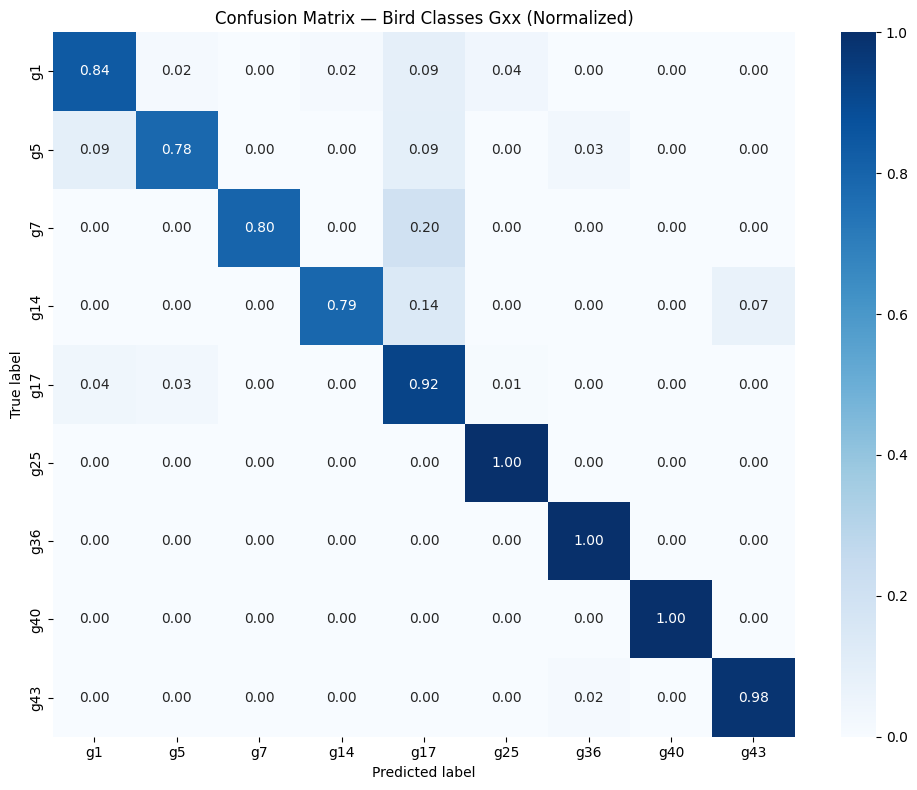

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(sub_norm, annot=True, fmt='.2f',
            xticklabels=bird_classes,
            yticklabels=bird_classes,
            cmap='Blues', vmin=0, vmax=1)
plt.title('Confusion Matrix — Bird Classes Gxx (Normalized)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_birds_v1.png', dpi=150)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import shutil
from pathlib import Path

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [ ]:
model =  YOLO(current_best_model)

In [ ]:
TEST_DIR = '/content/images2test/'
images   = list(Path(TEST_DIR).glob('*'))
images   = [f for f in images if f.suffix.lower()
            in {'.jpg','.jpeg','.png','.webp'}]
print(f'Found {len(images)} test images')

Found 0 test images


In [ ]:
!rm -rf images2test

In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

TEST_DIR = '/content/images2test/'
images   = list(Path(TEST_DIR).glob('*'))
images   = [f for f in images if f.suffix.lower()
            in {'.jpg','.jpeg','.png','.webp'}]
print(f'Found {len(images)} test images')

# Create the results directory if it doesn't exist
results_dir = '/content/results'
os.makedirs(results_dir, exist_ok=True)

for img_path in images:
    results = model(
        str(img_path),
        imgsz   = 1024,
        conf    = 0.25,    # umbral de confianza
        iou     = 0.30,    # permite overlap para signos apilados
        verbose = False
    )

    result = results[0]
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Imagen original
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original: {img_path.name}')
    axes[0].axis('off')

    # Imagen con detecciones
    axes[1].imshow(img_rgb)
    axes[1].set_title(f'Detections: {len(result.boxes)} signs found')
    axes[1].axis('off')

    detections = []
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf   = 1.5*float(box.conf[0])
        name   = model.names[cls_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Color por confianza
        if conf >= 0.80:
            color = 'lime'
        elif conf >= 0.50:
            color = 'yellow'
        else:
            color = 'red'

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        axes[1].add_patch(rect)
        axes[1].text(
            x1, y1-5, f'{name} {conf:.2f}',
            color='white', fontsize=7, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.7)
        )
        detections.append((name, conf))

    plt.tight_layout()
    plt.savefig(f'{results_dir}/result_{img_path.stem}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Secuencia de signos detectados
    print(f'\n{"="*50}')
    print(f'Image: {img_path.name}')
    print(f'Signs detected: {len(detections)}')
    print(f'{"Sign":10s}  {"Confidence":>10s}')
    print('-' * 25)
    for name, conf in detections:
        bar   = '█' * int(conf * 10)
        flag  = '✓' if conf >= 0.5 else '⚠' if conf >= 0.50 else '✗'
        print(f'{name:10s}  {conf:10.4f}  {bar} {flag}')
    print(f'{"="*50}\n')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
TEST_DIR = '/content/test_imgs2/'
images   = list(Path(TEST_DIR).glob('*'))
images   = [f for f in images if f.suffix.lower()
            in {'.jpg','.jpeg','.png','.webp'}]
print(f'Found {len(images)} test images')

# Create the results directory if it doesn't exist
results_dir = '/content/results'
os.makedirs(results_dir, exist_ok=True)

for img_path in images:
    results = model(
        str(img_path),
        imgsz   = 1024,
        conf    = 0.25,    # umbral de confianza
        iou     = 0.30,    # permite overlap para signos apilados
        verbose = False
    )

    result = results[0]
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Imagen original
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original: {img_path.name}')
    axes[0].axis('off')

    # Imagen con detecciones
    axes[1].imshow(img_rgb)
    axes[1].set_title(f'Detections: {len(result.boxes)} signs found')
    axes[1].axis('off')

    detections = []
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf   = 1.5*float(box.conf[0])
        name   = model.names[cls_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Color por confianza
        if conf >= 0.80:
            color = 'lime'
        elif conf >= 0.50:
            color = 'yellow'
        else:
            color = 'red'

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        axes[1].add_patch(rect)
        axes[1].text(
            x1, y1-5, f'{name} {conf:.2f}',
            color='white', fontsize=7, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.7)
        )
        detections.append((name, conf))

    plt.tight_layout()
    plt.savefig(f'{results_dir}/result_{img_path.stem}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Secuencia de signos detectados
    print(f'\n{"="*50}')
    print(f'Image: {img_path.name}')
    print(f'Signs detected: {len(detections)}')
    print(f'{"Sign":10s}  {"Confidence":>10s}')
    print('-' * 25)
    for name, conf in detections:
        bar   = '█' * int(conf * 10)
        flag  = '✓' if conf >= 0.5 else '⚠' if conf >= 0.50 else '✗'
        print(f'{name:10s}  {conf:10.4f}  {bar} {flag}')
    print(f'{"="*50}\n')

Output hidden; open in https://colab.research.google.com to view.

## Export Model to ONNX

In [ ]:
pip install onnx onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 129.2 MB/s eta 0:00:00


In [ ]:
# Define the path to save the ONNX model
onnx_path = f"{BASE_DIR}/shpinxVersionV3-2/weights/best.onnx"

# Export the model to ONNX format
results_export = best_model.export(
    format='onnx',
    opset=18,
    imgsz=1024, # Use the same image size used during training/validation
    name=onnx_path # Changed 'filename' to 'name'
)

print(f"Model successfully exported to: {onnx_path}")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/SphinxPV2/shpinxVersionV3-2/weights/best.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 154, 21504) (49.1 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 222ms
Prepared 3 packages in 2.30s
Installed 3 packages in 40ms
 + colorama==0.4.6
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 8.1s, saved as '/content/drive/MyDrive/S